# Week 5 Day 3 Lab

### Problem 1
*Gradient descent* on a function $f(x)$ in the two dimensional case works as follows:
1. Start with an initial value $x_0$.
2. Compute $f'(x_0)$.
3. 
    - If $f'(x_0)>0$, move to $x_0-\epsilon$. 
    - If $f'(x_0)<0$, move to $x_0+\epsilon$. 
    - If $f'(x_0)=0$, stay put.
4. Repeat steps 1-3 for a certain amount of iterations.

Create a function that performs gradient descent. Be careful: your function should take in an iteration number so it does not run forever.

In [3]:
import sympy as sp

def gradient_descent(f, x0, ep, iterations):
    x = sp.symbols('x')
    derivative = sp.diff(f, x)

    current = x0

    for i in range(iterations):
        slope = derivative.subs(x, current)

        if slope > 0:
            current -= ep
        elif slope < 0:
            current += ep
        else:
            break

    return current

x = sp.symbols('x')
f = x**2 + 2*x + 1

minimum = gradient_descent(f, 5, 0.1, 100)
print(minimum)

-0.999999999999999


### Problem 2
Your function from above should be able to find minima. Use `%timeit` to compare the run time of your function and `minimize` from the `scipy.optimize` library. Rerun for multiple different starting points.

In [7]:
from scipy.optimize import minimize

def g(x):
    return x[0]**2 + 2*x[0] + 1

# start at 5

%timeit gradient_descent(f, 5, 0.1, 100)

%timeit minimize(g, [5])

# start at 10

%timeit gradient_descent(f, -10, 0.1, 100)

%timeit minimize(g, [-10])

%timeit gradient_descent(f, 100, 0.1, 100)

%timeit minimize(g, [100])

2.93 ms ± 628 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
695 μs ± 51.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.8 ms ± 456 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.09 ms ± 155 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
3.1 ms ± 354 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.14 ms ± 286 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### Problem 3
Use `%timeit` to determine the speed of fitting a regression line by minimizing the sum of squared errors. Likewise, use `%timeit` to on using `np.polyfit()`. Was there a difference in speed?

In [10]:
import numpy as np


x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 3, 5, 4, 6])

def sse(params):
    m, b = params
    y_pred = m * x + b
    return np.sum((y - y_pred)**2)

%timeit minimize(sse, [0, 0])

%timeit np.polyfit(x, y, 1)

result = minimize(sse, [0, 0])
m1, b1 = result.x

m2, b2 = np.polyfit(x, y, 1)

print("minimize:", m1, b1)
print("polyfit :", m2, b2)

2.44 ms ± 238 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
33.9 μs ± 2.6 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
minimize: 0.899999929715926 1.30000017750371
polyfit : 0.8999999999999999 1.2999999999999985


### Problem 4 
The `loss()` function from lecture uses SSE as its error function. Define a new function `loss_2()` using a different error function. Plot the resulting lines for `loss()` and `loss_2()` on an example dataset.

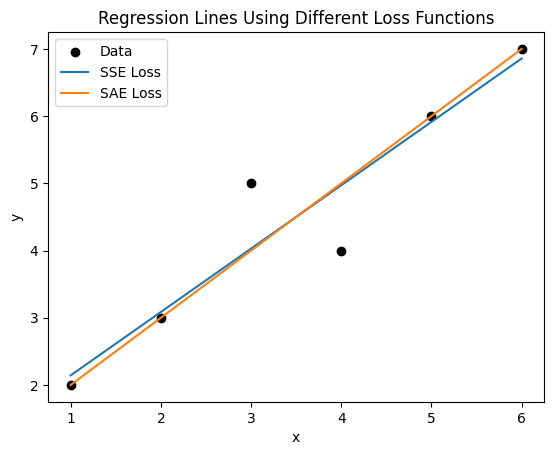

In [12]:
def loss(params):
    m, b = params
    y_pred = m * x + b
    return np.sum((y - y_pred)**2)

def loss_2(params):
    m, b = params
    y_pred = m * x + b
    return np.sum(np.abs(y - y_pred))

result1 = minimize(loss, [0, 0])
m1, b1 = result1.x

result2 = minimize(loss_2, [0, 0])
m2, b2 = result2.x

plt.scatter(x, y, color="black", label="Data")

plt.plot(x, m1*x + b1, label="SSE Loss")
plt.plot(x, m2*x + b2, label="SAE Loss")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression Lines Using Different Loss Functions")
plt.legend()

plt.show()